### Anomaly UniModel

In [5]:
# ==========================================
# STEP 6: PYTORCH ANOMALY DETECTION
# ==========================================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

model_output_path = '/mnt/shared_data/finflow/lstm_models'
test_matrix_path = '/mnt/shared_data/finflow/train_val_test_splits/test_total_fishing_hours.parquet'
anomaly_output_path = '/mnt/shared_data/finflow/anomalies/fishing_anomalies.parquet'
os.makedirs(os.path.dirname(anomaly_output_path), exist_ok=True)

# 1. Define Model Architecture
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 64), nn.ReLU(), nn.Linear(64, 1))
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :]).squeeze()

# 2. Setup PyTorch Dataset
class FishingTestDataset(Dataset):
    def __init__(self, parquet_path, lookback=12):
        print("Loading test data into memory...")
        self.df = pd.read_parquet(parquet_path)
        self.h3_indices = self.df['h3_index'].values
        self.month_cols = [c for c in self.df.columns if c != 'h3_index']
        self.data = self.df[self.month_cols].values.astype(np.float32)
        self.lookback = lookback
        print(f"Loaded {len(self.df):,} hex cells.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return self.data[idx], self.h3_indices[idx]

# 3. Initialize Everything
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel()
state_dict = torch.load(f'{model_output_path}/best_model.pt', map_location=device, weights_only=True)
if list(state_dict.keys())[0].startswith('_orig_mod.'):
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.to(device)
model.eval()

lookback = 12
anomaly_threshold_hours = 50.0  # We will refine this later!

test_dataset = FishingTestDataset(test_matrix_path, lookback)
# Use a massive batch size since inference uses very little VRAM
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False, num_workers=4)

anomalies = {
    "h3_index": [],
    "year_month": [],
    "actual_hours": [],
    "predicted_hours": [],
    "residual": []
}

# 4. Run Inference Loop
print("Scanning for anomalies...")
with torch.no_grad():
    for data_batch, h3_batch in tqdm(test_loader, desc="Processing Batches"):
        # We process all possible target months in a single batch
        for i in range(data_batch.shape[1] - lookback):
            target_month_idx = i + lookback
            target_month_str = test_dataset.month_cols[target_month_idx]
            
            # X shape: (batch_size, lookback), y shape: (batch_size,)
            X_np = data_batch[:, i:target_month_idx].numpy()
            y_actual_np = data_batch[:, target_month_idx].numpy()
            
            X_tensor = torch.tensor(np.log1p(X_np)).unsqueeze(-1).to(device)
            
            with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.bfloat16):
                y_pred_log = model(X_tensor)
            
            # Convert back from log space
            y_pred_np = np.expm1(y_pred_log.float().cpu().numpy())
            
            # Calculate Residual
            residuals = y_actual_np - y_pred_np
            
            # Find extreme deviations
            flagged_idx = np.where(residuals > anomaly_threshold_hours)[0]
            
            for idx in flagged_idx:
                anomalies["h3_index"].append(h3_batch[idx])
                anomalies["year_month"].append(target_month_str)
                anomalies["actual_hours"].append(round(float(y_actual_np[idx]), 2))
                anomalies["predicted_hours"].append(round(float(y_pred_np[idx]), 2))
                anomalies["residual"].append(round(float(residuals[idx]), 2))

# 5. Save Results
anomaly_df = pd.DataFrame(anomalies)
anomaly_df.to_parquet(anomaly_output_path, index=False)
print(f"\nDetection Complete! Found {len(anomaly_df):,} anomalies.")
print(f"Saved to: {anomaly_output_path}")

# Preview the top 5 largest anomalies
if len(anomaly_df) > 0:
    print("\nTop 5 Largest Anomalies (by residual):")
    print(anomaly_df.sort_values(by="residual", ascending=False).head())

Loading test data into memory...
Loaded 3,030,299 hex cells.
Scanning for anomalies...


Processing Batches: 100%|██████████| 304/304 [01:13<00:00,  4.13it/s]



Detection Complete! Found 369,248 anomalies.
Saved to: /mnt/shared_data/finflow/anomalies/fishing_anomalies.parquet

Top 5 Largest Anomalies (by residual):
               h3_index year_month  actual_hours  predicted_hours  residual
201322  8741b5948ffffff    2023-01       19955.0          4073.49  15881.51
32272   871ec93a4ffffff    2023-01       15852.0          5230.74  10621.26
35747   871ec93a4ffffff    2024-08       14951.0          5230.74   9720.26
35848   871ec93a4ffffff    2024-09       14494.0          5230.74   9263.26
32578   871ec93a4ffffff    2023-02       14123.0          5230.74   8892.26


--- Residual Statistics ---
Total Anomalies Found (Threshold > 50): 369,248
Mean Residual: 207.31
Median Residual: 128.02
90th Percentile: 416.74
99th Percentile: 1239.20
Max Residual: 15881.51


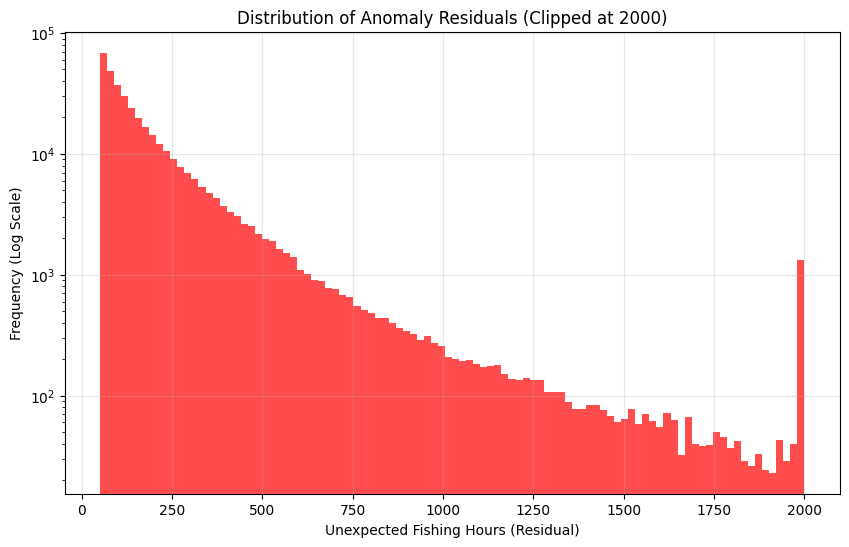


If we set the threshold to the 99th percentile (> 1239.20 hours):
We isolate the 3,693 most extreme events.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the anomalies we just found
anomaly_file = '/mnt/shared_data/finflow/anomalies/fishing_anomalies.parquet'
df_anomalies = pd.read_parquet(anomaly_file)

# Calculate some basic statistics on the residuals
print("--- Residual Statistics ---")
print(f"Total Anomalies Found (Threshold > 50): {len(df_anomalies):,}")
print(f"Mean Residual: {df_anomalies['residual'].mean():.2f}")
print(f"Median Residual: {df_anomalies['residual'].median():.2f}")
print(f"90th Percentile: {np.percentile(df_anomalies['residual'], 90):.2f}")
print(f"99th Percentile: {np.percentile(df_anomalies['residual'], 99):.2f}")
print(f"Max Residual: {df_anomalies['residual'].max():.2f}")

# Plot a quick histogram of the residuals to visualize the distribution
plt.figure(figsize=(10, 6))
# We clip at 2000 just to keep the plot readable, as the max is 15k+
plt.hist(df_anomalies['residual'].clip(upper=2000), bins=100, color='red', alpha=0.7)
plt.title('Distribution of Anomaly Residuals (Clipped at 2000)')
plt.xlabel('Unexpected Fishing Hours (Residual)')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Let's see how many are left if we only look at the top 1% most extreme events
top_1_percent_threshold = np.percentile(df_anomalies['residual'], 99)
extreme_anomalies = df_anomalies[df_anomalies['residual'] >= top_1_percent_threshold]

print(f"\nIf we set the threshold to the 99th percentile (> {top_1_percent_threshold:.2f} hours):")
print(f"We isolate the {len(extreme_anomalies):,} most extreme events.")

In [ ]:
import pandas as pd
import numpy as np
import folium
import h3

print("Loading anomalies and applying the 99th percentile threshold...")
anomaly_file = '/mnt/shared_data/finflow/anomalies/fishing_anomalies.parquet'
df_anomalies = pd.read_parquet(anomaly_file)

# 1. Filter for the top 1% most extreme events
threshold = 1239.20
extreme_anomalies = df_anomalies[df_anomalies['residual'] >= threshold].copy()
print(f"Isolated {len(extreme_anomalies):,} severe anomalies.")

# 2. Convert H3 index to Latitude/Longitude
def get_lat_lng(hex_id):
    # Note: Depending on your h3-py version, it might be h3_to_geo or cell_to_latlng
    try:
        return h3.h3_to_geo(hex_id)
    except AttributeError:
        return h3.cell_to_latlng(hex_id)

print("Decoding H3 spatial coordinates...")
extreme_anomalies['lat_lng'] = extreme_anomalies['h3_index'].apply(get_lat_lng)
extreme_anomalies['lat'] = extreme_anomalies['lat_lng'].apply(lambda x: x[0])
extreme_anomalies['lng'] = extreme_anomalies['lat_lng'].apply(lambda x: x[1])

# 3. Build the Interactive Map
print("Rendering map...")
# Center the map and use a dark theme to make the anomalies pop
m = folium.Map(location=[0, 0], zoom_start=2, tiles='CartoDB dark_matter')

for idx, row in extreme_anomalies.iterrows():
    # Scale the circle size based on the severity of the anomaly
    # Using square root so the 15k anomaly doesn't completely cover the screen
    radius_size = np.sqrt(row['residual']) / 4 
    
    # Create the hover-text
    popup_info = (
        f"<b>Month:</b> {row['year_month']}<br>"
        f"<b>Predicted:</b> {row['predicted_hours']:,.0f} hrs<br>"
        f"<b>Actual:</b> {row['actual_hours']:,.0f} hrs<br>"
        f"<b style='color:red;'>Anomaly Spike: +{row['residual']:,.0f} hrs</b>"
    )
    
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=radius_size,
        tooltip=popup_info,
        color='#ff4b4b',
        fill=True,
        fill_color='#ff4b4b',
        fill_opacity=0.6,
        weight=0.5
    ).add_to(m)

# 4. Save and Display
map_path = '/mnt/shared_data/finflow/anomalies/extreme_anomaly_map.html'
m.save(map_path)
print(f"Map saved successfully!")

# Calling 'm' at the end of a Jupyter cell renders the map interactively
m

### Anomaly MultiModel

In [2]:
# ==========================================
# MULTIVARIATE ANOMALY DETECTION (STREAMING)
# ==========================================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import os
from tqdm import tqdm

model_path = '/mnt/shared_data/finflow/lstm_models_multi/best_model_multi.pt'
base_path = '/mnt/shared_data/finflow/train_val_test_splits/'
anomaly_output_path = '/mnt/shared_data/finflow/anomalies/multivariate_baseline_anomalies.parquet'
os.makedirs(os.path.dirname(anomaly_output_path), exist_ok=True)

# 1. Define Multivariate Architecture
class LSTMModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 64), nn.ReLU(), nn.Linear(64, 1))
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :]).squeeze()

# 2. Initialize GPU & Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} (Bypassing Ray to use raw VRAM)")

model = LSTMModel(input_size=3, hidden_size=128, num_layers=2)

try:
    state_dict = torch.load(model_path, map_location=device, weights_only=True)
    if list(state_dict.keys())[0].startswith('_orig_mod.'):
        state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)
    print("Baseline multi-model weights loaded successfully!")
except Exception as e:
    print(f"Error loading model: {e}")

model.to(device)
model.eval()

# 3. Setup PyArrow Streaming (Zero RAM Overload)
print("Opening Parquet streams...")
pf_hours = pq.ParquetFile(os.path.join(base_path, 'test_total_fishing_hours.parquet'))
pf_pings = pq.ParquetFile(os.path.join(base_path, 'test_boat_ping_count.parquet'))
pf_sights = pq.ParquetFile(os.path.join(base_path, 'test_total_sighting_count.parquet'))

lookback = 12
anomaly_threshold_hours = 50.0
batch_size = 5000 # Only 5,000 rows in memory at any time!

anomalies = {
    "h3_index": [], "year_month": [], "actual_hours": [], "predicted_hours": [], "residual": []
}

# 4. The Streaming Inference Loop
print("Streaming data and scanning for anomalies...")

# We zip the iterators together so they stream in perfect sync
stream_zip = zip(
    pf_hours.iter_batches(batch_size=batch_size),
    pf_pings.iter_batches(batch_size=batch_size),
    pf_sights.iter_batches(batch_size=batch_size)
)

# Figure out total batches for the progress bar
total_batches = pf_hours.metadata.num_rows // batch_size + 1

with torch.no_grad():
    for batch_hours, batch_pings, batch_sights in tqdm(stream_zip, total=total_batches, desc="Streaming Batches"):
        
        # Convert the tiny 5k batch to Pandas instantly
        df_hours = batch_hours.to_pandas()
        df_pings = batch_pings.to_pandas()
        df_sights = batch_sights.to_pandas()
        
        h3_indices = df_hours['h3_index'].values
        month_cols = [c for c in df_hours.columns if c != 'h3_index']
        
        # Extract purely the numbers (shape: 5000, Num_Months)
        data_hours = df_hours[month_cols].values.astype(np.float32)
        data_pings = df_pings[month_cols].values.astype(np.float32)
        data_sights = df_sights[month_cols].values.astype(np.float32)
        
        # Stack them into our 3D tensor: (Batch, Months, 3 Features)
        data_stacked = np.stack([data_hours, data_pings, data_sights], axis=-1)
        
        # Scan across the months in this specific batch
        for i in range(data_stacked.shape[1] - lookback):
            target_month_idx = i + lookback
            target_month_str = month_cols[target_month_idx]
            
            # X shape: (5000, 12, 3)
            X_np = data_stacked[:, i:target_month_idx, :]
            
            # Y shape: (5000,) - Grab index 0 (Fishing Hours)
            y_actual_np = data_stacked[:, target_month_idx, 0]
            
            # Push to GPU
            X_tensor = torch.tensor(np.log1p(X_np)).to(device)
            
            # Predict
            with torch.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu', dtype=torch.bfloat16):
                y_pred_log = model(X_tensor)
            
            # Convert back from log space
            y_pred_np = np.expm1(y_pred_log.float().cpu().numpy())
            residuals = y_actual_np - y_pred_np
            
            # Flag anomalies
            flagged_idx = np.where(residuals > anomaly_threshold_hours)[0]
            
            for idx in flagged_idx:
                anomalies["h3_index"].append(h3_indices[idx])
                anomalies["year_month"].append(target_month_str)
                anomalies["actual_hours"].append(round(float(y_actual_np[idx]), 2))
                anomalies["predicted_hours"].append(round(float(y_pred_np[idx]), 2))
                anomalies["residual"].append(round(float(residuals[idx]), 2))

# 5. Save Results
anomaly_df = pd.DataFrame(anomalies)
if len(anomaly_df) > 0:
    anomaly_df.to_parquet(anomaly_output_path, index=False)
    print(f"\nDetection Complete! Found {len(anomaly_df):,} anomalies.")
    print(f"Saved to: {anomaly_output_path}")

    print("\nTop 5 Largest Anomalies (by residual):")
    print(anomaly_df.sort_values(by="residual", ascending=False).head())
else:
    print("\nNo anomalies found over the threshold!")

Using device: cuda (Bypassing Ray to use raw VRAM)
Baseline multi-model weights loaded successfully!
Opening Parquet streams...
Streaming data and scanning for anomalies...


Streaming Batches: 100%|██████████| 607/607 [02:41<00:00,  3.75it/s]



Detection Complete! Found 372,651 anomalies.
Saved to: /mnt/shared_data/finflow/anomalies/multivariate_baseline_anomalies.parquet

Top 5 Largest Anomalies (by residual):
               h3_index year_month  actual_hours  predicted_hours  residual
205369  8741b5948ffffff    2023-01       19955.0          3826.63  16128.37
32496   871ec93a4ffffff    2023-01       15852.0          5568.16  10283.84
35663   871ec93a4ffffff    2024-08       14951.0          5230.74   9720.26
35782   871ec93a4ffffff    2024-09       14494.0          5568.16   8925.84
32752   871ec93a4ffffff    2023-02       14123.0          5568.16   8554.84


--- Residual Statistics ---
Total Anomalies Found (Threshold > 50): 372,651
Mean Residual: 248.37
Median Residual: 144.97
90th Percentile: 533.35
99th Percentile: 1516.97
99.9th Percentile: 3419.38
Max Residual: 16128.37


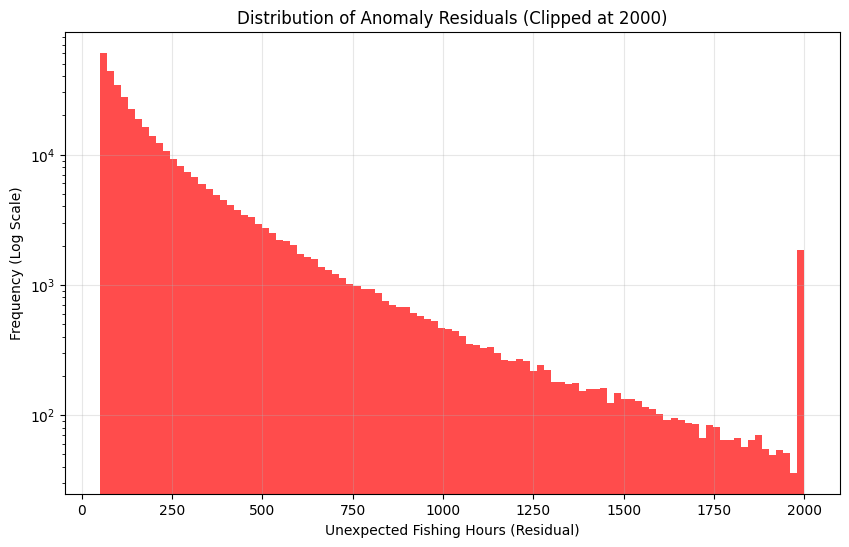


If we set the threshold to the 99th percentile (> 1516.97 hours):
We isolate the 3,727 most extreme events.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the anomalies we just found
anomaly_file = '/mnt/shared_data/finflow/anomalies/multivariate_baseline_anomalies.parquet'
df_anomalies = pd.read_parquet(anomaly_file)

# Calculate some basic statistics on the residuals
print("--- Residual Statistics ---")
print(f"Total Anomalies Found (Threshold > 50): {len(df_anomalies):,}")
print(f"Mean Residual: {df_anomalies['residual'].mean():.2f}")
print(f"Median Residual: {df_anomalies['residual'].median():.2f}")
print(f"90th Percentile: {np.percentile(df_anomalies['residual'], 90):.2f}")
print(f"99th Percentile: {np.percentile(df_anomalies['residual'], 99):.2f}")
print(f"99.9th Percentile: {np.percentile(df_anomalies['residual'], 99.9):.2f}")
print(f"Max Residual: {df_anomalies['residual'].max():.2f}")

# Plot a quick histogram of the residuals to visualize the distribution
plt.figure(figsize=(10, 6))
# We clip at 2000 just to keep the plot readable, as the max is 15k+
plt.hist(df_anomalies['residual'].clip(upper=2000), bins=100, color='red', alpha=0.7)
plt.title('Distribution of Anomaly Residuals (Clipped at 2000)')
plt.xlabel('Unexpected Fishing Hours (Residual)')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Let's see how many are left if we only look at the top 1% most extreme events
top_1_percent_threshold = np.percentile(df_anomalies['residual'], 99)
extreme_anomalies = df_anomalies[df_anomalies['residual'] >= top_1_percent_threshold]

print(f"\nIf we set the threshold to the 99th percentile (> {top_1_percent_threshold:.2f} hours):")
print(f"We isolate the {len(extreme_anomalies):,} most extreme events.")

In [ ]:
import pandas as pd
import numpy as np
import folium
import h3

print("Loading anomalies and applying the 99.9th percentile threshold...")
anomaly_file = '/mnt/shared_data/finflow/anomalies/multivariate_baseline_anomalies.parquet'
df_anomalies = pd.read_parquet(anomaly_file)

# 1. Dynamically calculate the top 0.1% threshold so you don't have to hardcode it!
threshold = np.percentile(df_anomalies['residual'], 99.5)
extreme_anomalies = df_anomalies[df_anomalies['residual'] >= threshold].copy()
print(f"Threshold set to {threshold:.2f} hrs. Isolated {len(extreme_anomalies):,} severe anomalies.")

# 2. Convert H3 index to Latitude/Longitude
def get_lat_lng(hex_id):
    try:
        return h3.h3_to_geo(hex_id)
    except AttributeError:
        return h3.cell_to_latlng(hex_id)

print("Decoding H3 spatial coordinates...")
extreme_anomalies['lat_lng'] = extreme_anomalies['h3_index'].apply(get_lat_lng)
extreme_anomalies['lat'] = extreme_anomalies['lat_lng'].apply(lambda x: x[0])
extreme_anomalies['lng'] = extreme_anomalies['lat_lng'].apply(lambda x: x[1])

# 3. Identify the Top 3 biggest anomalies to highlight
top_3_indices = extreme_anomalies.sort_values('residual', ascending=False).head(3).index

# 4. Build the Interactive Map
print("Rendering map...")
m = folium.Map(location=[0, 0], zoom_start=2, tiles='CartoDB dark_matter')

for idx, row in extreme_anomalies.iterrows():
    if idx not in top_3_indices:
        radius_size = np.sqrt(row['residual']) / 4 
        popup_info = f"<b>Month:</b> {row['year_month']}<br><b>Spike:</b> +{row['residual']:,.0f} hrs"
        
        folium.CircleMarker(
            location=[row['lat'], row['lng']], radius=radius_size, tooltip=popup_info,
            color='#ff4b4b', fill=True, fill_color='#ff4b4b', fill_opacity=0.6, weight=0.5
        ).add_to(m)

# 2. Draw the 3 BLUE dots LAST so they are guaranteed to sit on top!
for idx in top_3_indices:
    row = extreme_anomalies.loc[idx]
    radius_size = np.sqrt(row['residual']) / 4 
    popup_info = f"<b>CASE STUDY</b><br><b>Month:</b> {row['year_month']}<br><b>Spike:</b> +{row['residual']:,.0f} hrs"
    
    folium.CircleMarker(
        location=[row['lat'], row['lng']], radius=radius_size, tooltip=popup_info,
        color='#00a8ff', fill=True, fill_color='#00a8ff', fill_opacity=0.9, weight=1
    ).add_to(m)

# 5. Save and Display
map_path = '/mnt/shared_data/finflow/anomalies/_multivariate_baseline_extreme_anomaly_map.html'
m.save(map_path)
print(f"Map saved successfully!")

# Calling 'm' at the end of a Jupyter cell renders the map interactively

In [3]:
!pip install folium h3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]2m2/3 [folium]
